# 🗂️ Warehouse Reporting Automation — TablesCreator

**Author:** Giuseppe Iaccarino  
**Date:** December 2022 — Refactored 2026  
**Context:** Automated generation of 12 Excel operational reports from 7 source files exported from the WMS (Warehouse Management System) of a central distribution warehouse (Magazzino Badesse, Monteriggioni).

---

### Business Problem
Every week, the warehouse team had to manually build 12 Excel control reports by cross-referencing 7 different WMS exports. The process took hours, was error-prone, and produced inconsistent results depending on who ran it.

### Solution
A single Python script that loads all source files, joins and filters the data, and produces all 12 reports in under 60 seconds — with consistent formatting, buyer name enrichment, and automatic validation.

---

### Reports generated

| # | Report | Business purpose |
|---|---|---|
| 1 | STATO_E_CON_GIACENZA | Active articles with stock — coverage index |
| 2 | COPERTURA_OLTRE_8wk_NO_MKT | Overstock alert (>8 weeks coverage) |
| 3 | PALLETTIZAZIONI_ERRATE | Pallet height violations (>2.15m) |
| 4 | STATO_H_NO_GIACENZA | Suspended articles still holding stock |
| 5 | STATO_E_NO_GIACENZA | Active articles with empty shelf |
| 6 | STATO_T_CON_GIACENZA | Transit articles with residual stock |
| 7 | STATO_T_CON_GIACENZA_E_PRESA | Transit articles with stock and shelf slot |
| 8 | STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA | Transit with stock in shelf or reserve |
| 9 | STATO_F | Final-status articles |
| 10 | CONSEGNA_NO_PRESA_NO_VOL | Incoming deliveries with no shelf slot |
| 11 | STATO_O+S_NO_GIACENZA | On-order/seasonal with zero stock |
| 12 | CONTROLLO_SOSTITUZIONI | Substitution mapping verification |

---
*Source data not included — proprietary WMS export. All article descriptions and supplier names are anonymized.*

## 1. Setup & Configuration

In [1]:
import sys
import os
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

INPUT  = './INPUT/'
OUTPUT = './OUTPUT/'

RENAME_POSIZIONE = {
    'Presa: Corsia':     'Corsia',
    'Presa: Posto':      'Posto',
    'Presa: SottoPiano': 'Piano',
}
RENAME_DESC_STATO = {
    'Descrizione_x': 'Descrizione',
    'Stato_x':       'Stato',
}

pd.set_option('future.no_silent_downcasting', True)
print('Configuration loaded ✓')
print(f'INPUT  → {os.path.abspath(INPUT)}')
print(f'OUTPUT → {os.path.abspath(OUTPUT)}')

Configuration loaded ✓
INPUT  → /Users/colonic/Desktop/Etruria 2022/TablesCreator/INPUT
OUTPUT → /Users/colonic/Desktop/Etruria 2022/TablesCreator/OUTPUT


## 2. Utility Functions

In [2]:
def setup_output_dir(path: str) -> None:
    """Crea (o svuota) la cartella OUTPUT."""
    os.makedirs(path, exist_ok=True)
    shutil.rmtree(path)
    os.makedirs(path)
    print(f'Output directory ready: {os.path.abspath(path)}')


def load_excel(filename: str, **kwargs) -> pd.DataFrame:
    """Carica un file Excel da INPUT con gestione errori centralizzata."""
    filepath = INPUT + filename
    try:
        df = pd.read_excel(filepath, **kwargs)
        print(f'  ✓  {filename:45s}  {len(df):>6,} rows')
        return df
    except FileNotFoundError:
        print(f'  ✗  {filename} — FILE NON TROVATO')
    except Exception as e:
        print(f'  ✗  {filename} — ERRORE: {e}')
    return None


def add_buyer_names(df, df_buyer, buyer_col='Buyer', approv_col='Approv.'):
    """Arricchisce il df con Cognome_buyer e Cognome_approv."""
    df = (df.merge(df_buyer, left_on=buyer_col,  right_on='Codice', how='left')
            .rename(columns={'Cognome': 'Cognome_buyer'})
            .drop(columns='Codice', errors='ignore'))
    df = (df.merge(df_buyer, left_on=approv_col, right_on='Codice', how='left')
            .rename(columns={'Cognome': 'Cognome_approv'})
            .drop(columns='Codice', errors='ignore'))
    return df


_saved = []   # log dei file salvati, usato nel riepilogo finale

# Colonne con nomi di persone/aziende da mascherare per il portfolio pubblico
_NAME_COLS = ['Cognome_buyer', 'Cognome_approv', 'Des. Fornitore',
              'DesArticolo', 'Descrizione Fornitore', 'RAGIONE_SOCIALE',
              'Nome_x', 'Nome_y', 'Nome']

def _mask(val):
    """Mantieni i primi 3 caratteri, sostituisci il resto con xxx."""
    if pd.isna(val):
        return val
    s = str(val).strip()
    return s[:3] + 'xxx' if len(s) > 3 else s

def anonymize(df: pd.DataFrame) -> pd.DataFrame:
    """Applica _mask() a tutte le colonne sensibili presenti nel df."""
    df = df.copy()
    for col in _NAME_COLS:
        if col in df.columns:
            df[col] = df[col].apply(_mask)
    return df

def save(df: pd.DataFrame, filename: str) -> None:
    """Anonimizza nomi, salva in OUTPUT, logga dimensioni."""
    path = OUTPUT + filename
    anonymize(df).to_excel(path, index=False)
    _saved.append((filename, len(df), df.shape[1]))
    print(f'  → Salvato {filename}  ({len(df)} righe)')


print('Utility functions defined ✓')

Utility functions defined ✓


## 3. Setup Output Directory

In [3]:
setup_output_dir(OUTPUT)

Output directory ready: /Users/colonic/Desktop/Etruria 2022/TablesCreator/OUTPUT


## 4. Load Input Files

7 WMS exports loaded from `./INPUT/`. The script halts immediately if any file is missing.

In [4]:
t0 = time.time()
print('Loading INPUT files...\n')

df_rotazioni = load_excel('Rotazioni.xlsx', usecols=[
    'Articolo', 'Diff.', 'Descrizione', 'Stato', 'Giacenza IC', 'Giacenza PLT',
    'Media Vendite IC STD', 'Settimane Copertura', 'Rotazioni', 'Indice Copertura STD',
    'Data Ultimo Carico', 'Fornitore', 'Diff. Fornitore', 'Des. Fornitore',
    'Buyer', 'Approv.', 'IC', 'IF', 'PLT', 'L1', 'L2', 'L3', 'L4', 'Descr. 4° Livello'])

df_sostituzioni = load_excel('Sostituzioni.xlsx')

df_ordini = load_excel('Ordini Fornitori.xlsx', usecols=[
    'Fornitore', 'Diff.', 'Des. Fornitore', 'Data Consegna', 'Articolo', 'Diff',
    'DesArticolo', 'Stato Riga', 'Des Stato Riga', 'Qta Ordine IF', 'Qta Ordine PZ',
    'Qta Consegna IF', 'Qta Consegna PZ'])

df_prese      = load_excel('Mappa Prese.xlsx')
df_buyer      = load_excel('BuyerApprov.xlsx')

df_corsie = load_excel('Giacenza Corsie.xlsx', usecols=[
    'Codice', 'Diff', 'Descrizione', 'Stato', 'Qta Pezzi Presa',
    'Qta Pezzi Scorta', 'Giacenza Contabile: Pezzi'])

df_anagrafica = load_excel('Controllo Anagrafica.xlsx', usecols=[
    'Cod', 'Dif', 'Descrizione', 'Stato', 'L1', 'L2', 'L3', 'L4', 'Prog.',
    'Des. Merceologia', 'Fornitore', 'Diff', 'Descrizione Fornitore', 'Da Pesare',
    'Shelf Life', 'GG Accettaz.', 'Lotto Obb.', 'Buyer', 'Approv.',
    'Alto-PZ', 'Largo-PZ', 'Prof-PZ', 'IF Strato', 'N° Strati',
    'Alto-IC', 'Largo-IC', 'Prof-IC'])

missing = [name for name, df in [
    ('Rotazioni', df_rotazioni), ('Sostituzioni', df_sostituzioni),
    ('Ordini Fornitori', df_ordini), ('Mappa Prese', df_prese),
    ('BuyerApprov', df_buyer), ('Giacenza Corsie', df_corsie),
    ('Controllo Anagrafica', df_anagrafica)] if df is None]

if missing:
    raise SystemExit(f'File mancanti: {missing}. Operazione interrotta.')

print(f'\nAll {7} files loaded successfully ✓')

Loading INPUT files...

  ✓  Rotazioni.xlsx                                  8,705 rows
  ✓  Sostituzioni.xlsx                                 255 rows
  ✓  Ordini Fornitori.xlsx                           2,118 rows
  ✓  Mappa Prese.xlsx                                6,829 rows
  ✓  BuyerApprov.xlsx                                   23 rows
  ✓  Giacenza Corsie.xlsx                            6,829 rows
  ✓  Controllo Anagrafica.xlsx                       8,832 rows

All 7 files loaded successfully ✓


## 5. Data Wrangling

Date formatting, NaN normalization, and pre-computation of the `Altezza Teorica PLT` service table (used by multiple reports).

In [5]:
print('Data wrangling...')

df_sostituzioni.replace('99/99/9999', np.nan, inplace=True)
df_anagrafica['Shelf Life'].replace(99999, np.nan, inplace=True)

df_sostituzioni['Scadenza Sostituzione'] = (
    pd.to_datetime(df_sostituzioni['Scadenza Sostituzione'], format='%d/%m/%Y')
    .dt.strftime('%d/%m/%Y'))

df_rotazioni['Data Ultimo Carico'] = (
    pd.to_datetime(df_rotazioni['Data Ultimo Carico'], format='%d/%m/%Y')
    .dt.strftime('%d/%m/%Y'))

df_ordini['Data Consegna'] = (
    pd.to_datetime(df_ordini['Data Consegna'], format='%Y%m%d')
    .dt.strftime('%d/%m/%Y'))

# Service table: theoretical pallet height
# Formula: (strati × altezza IC + 15 cm pallet base) / 100 → meters
df_altezza_teorica_plt = df_anagrafica[
    ['Cod', 'Dif', 'Descrizione', 'Stato', 'N° Strati', 'Alto-IC']].copy()
df_altezza_teorica_plt['Altezza Teorica PLT'] = (
    (df_altezza_teorica_plt['N° Strati'] * df_altezza_teorica_plt['Alto-IC']) + 15) / 100

print(f'  Altezza Teorica PLT computed for {len(df_altezza_teorica_plt):,} articles')
print('  Date columns formatted ✓')
print('  NaN normalization done ✓')
print('\nData wrangling complete ✓')

Data wrangling...
  Altezza Teorica PLT computed for 8,832 articles
  Date columns formatted ✓
  NaN normalization done ✓

Data wrangling complete ✓


## 6. Report Generation

Each section below produces one Excel report.  
A preview of the first 5 rows is shown for each output so the structure is visible without opening the files.

In [6]:
# ── STATO_E_CON_GIACENZA ────────────────────────────────────────
print('\nSTATO_E_CON_GIACENZA')
print('Active articles (Stato=E) with stock — sorted by coverage index descending.')
df = (df_anagrafica
      .merge(df_corsie,    left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
      .merge(df_rotazioni, left_on=('Cod', 'Dif'), right_on=('Articolo', 'Diff.')))
df = df[['Cod', 'Dif', 'Descrizione', 'Stato', 'Qta Pezzi Presa', 'Qta Pezzi Scorta',
         'Indice Copertura STD', 'Buyer_y', 'Approv._x']]
df.rename(columns={'Buyer_y': 'Buyer', 'Approv._x': 'Approv.'}, inplace=True)
df['Indice Copertura STD'] = df['Indice Copertura STD'].round(1)
df = df[df['Stato'] == 'E'].sort_values('Indice Copertura STD', ascending=False)
df = add_buyer_names(df, df_buyer)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_E_CON_GIACENZA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_E_CON_GIACENZA
Active articles (Stato=E) with stock — sorted by coverage index descending.
  → Salvato STATO_E_CON_GIACENZA.xlsx  (234 righe)
Shape: 234 rows × 13 cols


,Cod,Dif,Descrizione,Stato,Qta Pezzi Presa,Qta Pezzi Scorta,Indice Copertura STD,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,20365,3,ETICHETT.NEUTRE GIALLE SCAFF.A4X200 ...,E,2777,NaN,6664.8,560,560,CED,CED,CED,CED
1,119156,2,GEOMAR TERMO CREMA PUN.CRITICI 150M ...,E,102,114.0,72.0,300,302,GUExxx,ANTxxx,BIAxxx,VALxxx
2,3771,1,"VASO BORMIOLI S/TAPPO KG 1,5 ...",E,156,942.0,52.3,300,302,GUExxx,ANTxxx,BIAxxx,VALxxx
3,105287,1,+CONF.4 BOTTIGLIE VECCHIA CANTINA ...,E,23,187.0,45.8,400,231,VALxxx,FABxxx,BORxxx,PAOxxx
4,150091,1,OLAY REGENERIST 3ZONE CR.GIORNO 50M ...,E,132,40.0,43.0,300,302,GUExxx,ANTxxx,BIAxxx,VALxxx


In [7]:
# ── COPERTURA_OLTRE_8wk_NO_MKT ──────────────────────────────────
print('\nCOPERTURA_OLTRE_8wk_NO_MKT')
print('Overstock alert: active articles with ≥8 weeks coverage, excluding marketing categories (L1: 69, 70).')
df = df_rotazioni.merge(df_corsie, left_on=('Articolo', 'Diff.'), right_on=('Codice', 'Diff'))
df = df[['Articolo', 'Diff.', 'Descrizione_x', 'Stato_x', 'Giacenza IC',
         'Qta Pezzi Scorta', 'Media Vendite IC STD', 'Indice Copertura STD',
         'Fornitore', 'Diff. Fornitore', 'Des. Fornitore', 'Buyer', 'Approv.',
         'L1', 'L2', 'L3', 'L4', 'Descr. 4° Livello']]
df = df[(df['Indice Copertura STD'] >= 8) & (~df['L1'].isin([69, 70]))]
for col in ['Giacenza IC', 'Media Vendite IC STD', 'Indice Copertura STD']:
    df[col] = df[col].round(1)
df = add_buyer_names(df, df_buyer)
df.rename(columns={**RENAME_DESC_STATO}, inplace=True)
df.sort_values(['Stato', 'Indice Copertura STD'], ascending=[True, False], inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'COPERTURA_OLTRE_8wk_NO_MKT.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


COPERTURA_OLTRE_8wk_NO_MKT
Overstock alert: active articles with ≥8 weeks coverage, excluding marketing categories (L1: 69, 70).
  → Salvato COPERTURA_OLTRE_8wk_NO_MKT.xlsx  (292 righe)
Shape: 292 rows × 22 cols


,Articolo,Diff.,Descrizione,Stato,Giacenza IC,Qta Pezzi Scorta,Media Vendite IC STD,Indice Copertura STD,Fornitore,Diff. Fornitore,...,Approv.,L1,L2,L3,L4,Descr. 4° Livello,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,119156,2,GEOMAR TERMO CREMA PUN.CRITICI 150M ...,E,36.0,114.0,0.5,72.0,10903,2,...,302,46,40,10,60,TRATTAMENTI RASSOD/MODEL/RIDUC,GUExxx,ANTxxx,BIAxxx,VALxxx
1,3771,1,"VASO BORMIOLI S/TAPPO KG 1,5 ...",E,183.0,942.0,3.5,52.3,3151,1,...,302,44,90,60,10,ACCESSORI PREPARAZI. ALIMENTI,GUExxx,ANTxxx,BIAxxx,VALxxx
2,105287,1,+CONF.4 BOTTIGLIE VECCHIA CANTINA ...,E,210.0,187.0,4.6,45.8,16720,1,...,231,42,40,20,20,VINO DOC/DOCG ITALIANO ROSSO,VALxxx,FABxxx,BORxxx,PAOxxx
3,150091,1,OLAY REGENERIST 3ZONE CR.GIORNO 50M ...,E,43.0,40.0,1.0,43.0,16828,1,...,302,46,60,40,20,CREMA ANTIRUGHE,GUExxx,ANTxxx,BIAxxx,VALxxx
4,117756,2,LIQUIDO IGIENIZZANTE 120 ML ...,E,225.8,11220.0,6.0,37.6,2822,2,...,302,46,90,30,20,ALTRO PARAFARMACIA - VARIE,GUExxx,ANTxxx,BIAxxx,VALxxx


In [8]:
# ── PALLETTIZAZIONI_ERRATE ──────────────────────────────────────
print('\nPALLETTIZAZIONI_ERRATE')
print('Articles whose theoretical pallet height exceeds 2.15m — a safety and storage compliance issue.')
df = df_anagrafica.merge(df_altezza_teorica_plt, on=('Cod', 'Dif'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'IF Strato', 'N° Strati_y',
         'Alto-IC_x', 'Largo-IC', 'Prof-IC', 'Altezza Teorica PLT', 'Buyer', 'Approv.']]
df = df[df['Altezza Teorica PLT'] > 2.15]
df.rename(columns={**RENAME_DESC_STATO,
                   'N° Strati_y': 'N° Strati', 'Alto-IC_x': 'Alto-IC'}, inplace=True)
df = add_buyer_names(df, df_buyer)
df.sort_values('Altezza Teorica PLT', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'PALLETTIZAZIONI_ERRATE.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


PALLETTIZAZIONI_ERRATE
Articles whose theoretical pallet height exceeds 2.15m — a safety and storage compliance issue.
  → Salvato PALLETTIZAZIONI_ERRATE.xlsx  (2253 righe)
Shape: 2253 rows × 16 cols


,Cod,Dif,Descrizione,Stato,IF Strato,N° Strati,Alto-IC,Largo-IC,Prof-IC,Altezza Teorica PLT,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,4026,1,"+CAFFE""SPLENDID CLASS. GR.250X2 ...",O,14,6,326,186,146,19.71,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx
1,117057,1,MANICO IN METALLO CRF ...,I,20,10,132,4,14,13.35,300,302,GUExxx,ANTxxx,BIAxxx,VALxxx
2,115132,2,TORTA ROLL G300 CIOC.BIANCO GECCHE ...,I,9,32,39,6,23,12.63,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx
3,115132,1,TORTA ROLL G300 CAPPUCCINO GECCHELE ...,I,9,32,39,6,23,12.63,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx
4,115130,1,TORTA ROTOLO LIMONE T400 GECCHELE ...,I,8,28,38,7,30,10.79,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx


In [9]:
# ── STATO_H_NO_GIACENZA ─────────────────────────────────────────
print('\nSTATO_H_NO_GIACENZA')
print('Suspended articles (Stato=H) with zero stock in shelf or warehouse — safe to delist.')
df = (df_anagrafica
      .merge(df_corsie,    left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
      .merge(df_rotazioni, left_on=('Cod', 'Dif'), right_on=('Articolo', 'Diff.')))
df = df[['Cod', 'Dif', 'Descrizione', 'Stato', 'Qta Pezzi Presa', 'Giacenza Contabile: Pezzi']]
df = df[(df['Stato'] == 'H') &
        ((df['Qta Pezzi Presa'] == 0) | (df['Giacenza Contabile: Pezzi'] == 0))]
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_H_NO_GIACENZA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_H_NO_GIACENZA
Suspended articles (Stato=H) with zero stock in shelf or warehouse — safe to delist.
  → Salvato STATO_H_NO_GIACENZA.xlsx  (2 righe)
Shape: 2 rows × 6 cols


,Cod,Dif,Descrizione,Stato,Qta Pezzi Presa,Giacenza Contabile: Pezzi
0,107311,1,VOL AU VENT BIANCOFORNO G150 VASC. ...,H,0,0
1,107736,1,BIGNOLINE CABRIONI GR.100 ...,H,15,0


In [10]:
# ── STATO_E_NO_GIACENZA ─────────────────────────────────────────
print('\nSTATO_E_NO_GIACENZA')
print('Active articles (Stato=E) with empty shelf or zero warehouse stock — potential stockout risk.')
df = (df_anagrafica
      .merge(df_prese,  left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
      .merge(df_corsie, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff')))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Presa: Corsia', 'Presa: Posto',
         'Presa: SottoPiano', 'Qta Pezzi Presa', 'Qta Pezzi Scorta', 'Giacenza Contabile: Pezzi']]
df = df[(df['Stato_x'] == 'E') &
        ((df['Qta Pezzi Presa'] <= 0) | (df['Giacenza Contabile: Pezzi'] <= 0))]
df.rename(columns={**RENAME_DESC_STATO, **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_E_NO_GIACENZA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_E_NO_GIACENZA
Active articles (Stato=E) with empty shelf or zero warehouse stock — potential stockout risk.
  → Salvato STATO_E_NO_GIACENZA.xlsx  (11 righe)
Shape: 11 rows × 10 cols


,Cod,Dif,Descrizione,Stato,Corsia,Posto,Piano,Qta Pezzi Presa,Qta Pezzi Scorta,Giacenza Contabile: Pezzi
0,5857,1,PROFITEROLES BAULI GR.750 ...,E,24,74,1,0,NaN,18
1,14794,1,PANETTONE CIOCOSOFFICE BAULI G750 ...,E,A2,164,1,0,NaN,0
2,107262,2,PAMPERS BABY DRY MAXI X52 . ...,E,13,26,1,0,NaN,0
3,107262,3,PAMPERS BABY DRY JUNIOR X44. . ...,E,13,128,1,0,NaN,0
4,111043,1,+CONF.3BTG CANT.MORELLINO CL75 ...,E,A2,51,2,4,NaN,0


In [11]:
# ── STATO_T_CON_GIACENZA ────────────────────────────────────────
print('\nSTATO_T_CON_GIACENZA')
print('Transit articles (Stato=T) still holding stock — should have been cleared before transition.')
df = df_anagrafica.merge(df_corsie, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Qta Pezzi Presa',
         'Giacenza Contabile: Pezzi', 'Buyer', 'Approv.']]
df = df[(df['Stato_x'] == 'T') &
        (df['Qta Pezzi Presa'] > 0) & (df['Giacenza Contabile: Pezzi'] > 0)]
df = add_buyer_names(df, df_buyer)
df.rename(columns=RENAME_DESC_STATO, inplace=True)
df.sort_values(['Qta Pezzi Presa', 'Giacenza Contabile: Pezzi'], ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_T_CON_GIACENZA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_T_CON_GIACENZA
Transit articles (Stato=T) still holding stock — should have been cleared before transition.
  → Salvato STATO_T_CON_GIACENZA.xlsx  (1 righe)
Shape: 1 rows × 12 cols


,Cod,Dif,Descrizione,Stato,Qta Pezzi Presa,Giacenza Contabile: Pezzi,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,104355,1,BISCOTTI GIAMPAOLI ZUCCHERELLI KG1 ...,T,48,1408,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx


In [12]:
# ── STATO_T_CON_GIACENZA_E_PRESA ────────────────────────────────
print('\nSTATO_T_CON_GIACENZA_E_PRESA')
print('Transit articles with stock AND an assigned shelf slot — location info for physical clearance.')
df = df_anagrafica.merge(df_corsie, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Qta Pezzi Presa',
         'Giacenza Contabile: Pezzi', 'Buyer', 'Approv.']]
df = df[(df['Stato_x'] == 'T') &
        (df['Qta Pezzi Presa'] > 0) & (df['Giacenza Contabile: Pezzi'] > 0)]
df = df.merge(df_prese, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Presa: Corsia', 'Presa: Posto',
         'Presa: SottoPiano', 'Qta Pezzi Presa', 'Giacenza Contabile: Pezzi',
         'Buyer_x', 'Approv.']]
df.rename(columns={'Buyer_x': 'Buyer'}, inplace=True)
df = add_buyer_names(df, df_buyer)
df.rename(columns={**RENAME_DESC_STATO, **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_T_CON_GIACENZA_E_PRESA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_T_CON_GIACENZA_E_PRESA
Transit articles with stock AND an assigned shelf slot — location info for physical clearance.
  → Salvato STATO_T_CON_GIACENZA_E_PRESA.xlsx  (1 righe)
Shape: 1 rows × 15 cols


,Cod,Dif,Descrizione,Stato,Corsia,Posto,Piano,Qta Pezzi Presa,Giacenza Contabile: Pezzi,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,104355,1,BISCOTTI GIAMPAOLI ZUCCHERELLI KG1 ...,T,9,128,2,48,1408,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx


In [13]:
# ── STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA ──────────────────────
print('\nSTATO_T_CON_GIACENZA_in_PRESA_o_SCORTA')
print('Transit articles with stock in shelf OR reserve — broader clearance list.')
df = df_anagrafica.merge(df_corsie, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Qta Pezzi Presa',
         'Giacenza Contabile: Pezzi', 'Qta Pezzi Scorta', 'Buyer', 'Approv.']]
df = df[(df['Stato_x'] == 'T') &
        (((df['Qta Pezzi Presa'] > 0) & (df['Giacenza Contabile: Pezzi'] > 0)) |
          (df['Qta Pezzi Scorta'] > 0))]
df = df.merge(df_prese, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Presa: Corsia', 'Presa: Posto',
         'Presa: SottoPiano', 'Qta Pezzi Presa', 'Giacenza Contabile: Pezzi',
         'Qta Pezzi Scorta', 'Buyer_x', 'Approv.']]
df.rename(columns={'Buyer_x': 'Buyer'}, inplace=True)
df = add_buyer_names(df, df_buyer)
df.rename(columns={**RENAME_DESC_STATO, **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA
Transit articles with stock in shelf OR reserve — broader clearance list.
  → Salvato STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA.xlsx  (4 righe)
Shape: 4 rows × 16 cols


,Cod,Dif,Descrizione,Stato,Corsia,Posto,Piano,Qta Pezzi Presa,Giacenza Contabile: Pezzi,Qta Pezzi Scorta,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y
0,104355,1,BISCOTTI GIAMPAOLI ZUCCHERELLI KG1 ...,T,9,128,2,48,1408,1344.0,303,242,FIAxxx,DAVxxx,MOMxxx,DAVxxx
1,112844,1,"CHIANTI DOCG CORTELUNGA LT 1,5 ...",T,A4,50,1,0,48,48.0,400,231,VALxxx,FABxxx,BORxxx,PAOxxx
2,116020,1,CHIANTI RUFINA DOCG RIS.GRIGN.CL75 ...,T,A4,46,2,0,150,150.0,400,231,VALxxx,FABxxx,BORxxx,PAOxxx
3,151340,1,BIRRA PERONI BOTT.VAP CL.66 ...,T,A6,65,1,0,20790,17820.0,400,302,VALxxx,FABxxx,BIAxxx,VALxxx


In [14]:
# ── STATO_F ─────────────────────────────────────────────────────
print('\nSTATO_F')
print('Final-status articles (Stato=F) still occupying shelf space.')
df = df_prese.merge(df_corsie, on=('Codice', 'Diff'))
df = df[['Codice', 'Diff', 'Descrizione_x', 'Stato_x', 'Presa: Corsia', 'Presa: Posto',
         'Presa: SottoPiano', 'Qta Pezzi Presa', 'Qta Pezzi Scorta', 'Giacenza Contabile: Pezzi']]
df = df[df['Stato_x'] == 'F']
df.rename(columns={**RENAME_DESC_STATO, **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_F.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_F
Final-status articles (Stato=F) still occupying shelf space.
  → Salvato STATO_F.xlsx  (24 righe)
Shape: 24 rows × 10 cols


,Codice,Diff,Descrizione,Stato,Corsia,Posto,Piano,Qta Pezzi Presa,Qta Pezzi Scorta,Giacenza Contabile: Pezzi
0,19605,1,PANETT. S/CANDITI LE TRE MARIE KG.1 ...,F,A2,166,1,0,NaN,0
1,115738,1,+EXPO HAG BAR CLASS.160+40 OMAG. ...,F,24,481,1,0,NaN,0
2,116747,1,"POLPA POMOD.FINE KG 2,5 LATTA MUTTI ...",F,24,473,1,0,NaN,0
3,116748,1,"DOPPIO CONCENT.KG 2,15 LATTA MUTTI ...",F,24,472,1,0,NaN,0
4,116749,1,DOPPIO CONCENT.GR 880 LATTA MUTTI ...,F,24,471,1,0,NaN,0


In [15]:
# ── CONSEGNA_NO_PRESA_NO_VOL ────────────────────────────────────
print('\nCONSEGNA_NO_PRESA_NO_VOL')
print('Incoming supplier deliveries with no shelf slot assigned — requires logistics intervention before arrival.')
df = (df_ordini
      .merge(df_prese,               left_on=('Articolo', 'Diff'), right_on=('Codice', 'Diff'))
      .merge(df_altezza_teorica_plt,  left_on=('Articolo', 'Diff'), right_on=('Cod', 'Dif')))
df = df[['Data Consegna', 'Articolo', 'Diff', 'DesArticolo', 'Stato_y',
         'Qta Ordine IF', 'Qta Consegna IF', 'Stato Riga', 'Des Stato Riga',
         'Altezza Teorica PLT', 'Presa: Corsia', 'Presa: Posto', 'Presa: SottoPiano']]
df = df[~df['DesArticolo'].str.contains('VOL\\.', na=False) &
        ~df['DesArticolo'].str.contains('VOLANT', na=False) &
         df['Presa: Posto'].isnull()]
df.sort_values('Data Consegna', inplace=True)
df.rename(columns={'Stato_y': 'Stato', **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'CONSEGNA_NO_PRESA_NO_VOL.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


CONSEGNA_NO_PRESA_NO_VOL
Incoming supplier deliveries with no shelf slot assigned — requires logistics intervention before arrival.
  → Salvato CONSEGNA_NO_PRESA_NO_VOL.xlsx  (0 righe)
Shape: 0 rows × 13 cols


,Data Consegna,Articolo,Diff,DesArticolo,Stato,Qta Ordine IF,Qta Consegna IF,Stato Riga,Des Stato Riga,Altezza Teorica PLT,Corsia,Posto,Piano


In [16]:
# ── STATO_O+S_NO_GIACENZA ───────────────────────────────────────
print('\nSTATO_O+S_NO_GIACENZA')
print('On-order or seasonal articles (Stato O/S) with no stock and no scheduled delivery — potential ghost records.')
df = df_anagrafica.merge(df_corsie, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df[['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Qta Pezzi Presa',
         'Qta Pezzi Scorta', 'Giacenza Contabile: Pezzi']]
df = df.merge(df_prese, left_on=('Cod', 'Dif'), right_on=('Codice', 'Diff'))
df = df.merge(df_ordini, left_on=('Cod', 'Dif'), right_on=('Articolo', 'Diff'))
df = df.reindex(columns=['Cod', 'Dif', 'Descrizione_x', 'Stato_x', 'Data Consegna',
                          'Presa: Corsia', 'Presa: Posto', 'Presa: SottoPiano',
                          'Qta Pezzi Presa', 'Qta Pezzi Scorta',
                          'Giacenza Contabile: Pezzi', 'Buyer', 'Approv.'])
df = df[(df['Data Consegna'].isnull()) &
        (df['Stato_x'].isin(['S', 'O'])) &
        (df['Qta Pezzi Presa'] == 0) &
        (df['Giacenza Contabile: Pezzi'] == 0)]
df = add_buyer_names(df, df_buyer)
df.rename(columns={**RENAME_DESC_STATO, **RENAME_POSIZIONE}, inplace=True)
df.reset_index(drop=True, inplace=True)
save(df, 'STATO_O+S_NO_GIACENZA.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


STATO_O+S_NO_GIACENZA
On-order or seasonal articles (Stato O/S) with no stock and no scheduled delivery — potential ghost records.
  → Salvato STATO_O+S_NO_GIACENZA.xlsx  (0 righe)
Shape: 0 rows × 17 cols


,Cod,Dif,Descrizione,Stato,Data Consegna,Corsia,Posto,Piano,Qta Pezzi Presa,Qta Pezzi Scorta,Giacenza Contabile: Pezzi,Buyer,Approv.,Cognome_buyer,Nome_x,Cognome_approv,Nome_y


In [17]:
# ── CONTROLLO_SOSTITUZIONI ──────────────────────────────────────
print('\nCONTROLLO_SOSTITUZIONI')
print('Substitution pairs where both articles have a shelf slot and the original is suspended (H) — actionable swap list.')
df = df_sostituzioni.merge(df_prese, left_on=('Articolo', 'Diff'), right_on=('Codice', 'Diff'))
df = df[['Articolo', 'Diff', 'Descrizione_x', 'Stato_x', 'Presa: Qta Pezzi',
         'Gia Cont PZ', 'Presa: Corsia', 'Presa: Posto', 'Presa: Lato', 'Presa: Piano',
         'Presa: SottoPiano', 'Articolo.1', 'Diff.1', 'Descrizione.1', 'Stato.1']]
df.rename(columns={'Descrizione_x': 'Descrizione', 'Stato_x': 'Stato'}, inplace=True)

df = df.merge(df_prese, left_on=('Articolo.1', 'Diff.1'), right_on=('Codice', 'Diff'))
df = df[['Articolo', 'Diff_x', 'Descrizione_x', 'Stato_x', 'Presa: Qta Pezzi_x',
         'Gia Cont PZ', 'Presa: Corsia_x', 'Presa: Posto_x', 'Presa: Lato_x',
         'Presa: Piano_x', 'Presa: SottoPiano_x',
         'Articolo.1', 'Diff.1', 'Descrizione.1', 'Stato.1',
         'Presa: Qta Pezzi_y', 'Presa: Corsia_y', 'Presa: Posto_y',
         'Presa: Lato_y', 'Presa: Piano_y', 'Presa: SottoPiano_y']]
df = df[(df['Stato_x'] == 'H') &
        df['Presa: Posto_x'].notna() &
        df['Presa: Posto_y'].notna()]
for suf in ('_x', '_y'):
    df[f'Posizione{suf}'] = (df[f'Presa: Corsia{suf}'].astype(str) + ' - ' +
                              df[f'Presa: Posto{suf}'].astype(str)  + ' - P.' +
                              df[f'Presa: SottoPiano{suf}'].astype(str))
df = df[['Articolo', 'Diff_x', 'Descrizione_x', 'Stato_x', 'Presa: Qta Pezzi_x',
         'Gia Cont PZ', 'Posizione_x', 'Articolo.1', 'Diff.1', 'Descrizione.1',
         'Stato.1', 'Presa: Qta Pezzi_y', 'Posizione_y']]
df.rename(columns={
    'Articolo': 'Articolo.A', 'Diff_x': 'Diff.A',
    'Descrizione_x': 'Descrizione.A', 'Stato_x': 'Stato.A',
    'Presa: Qta Pezzi_x': 'Presa: Qta Pezzi.A', 'Gia Cont PZ': 'Gia Cont PZ.A',
    'Posizione_x': 'Posizione.A',
    'Articolo.1': 'Articolo.B', 'Diff.1': 'Diff.B',
    'Descrizione.1': 'Descrizione.B', 'Stato.1': 'Stato.B',
    'Presa: Qta Pezzi_y': 'Presa: Qta Pezzi.B', 'Posizione_y': 'Posizione.B',
}, inplace=True)
save(df, 'CONTROLLO_SOSTITUZIONI.xlsx')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} cols')
display(anonymize(df).head())


CONTROLLO_SOSTITUZIONI
Substitution pairs where both articles have a shelf slot and the original is suspended (H) — actionable swap list.
  → Salvato CONTROLLO_SOSTITUZIONI.xlsx  (1 righe)
Shape: 1 rows × 13 cols


,Articolo.A,Diff.A,Descrizione.A,Stato.A,Presa: Qta Pezzi.A,Gia Cont PZ.A,Posizione.A,Articolo.B,Diff.B,Descrizione.B,Stato.B,Presa: Qta Pezzi.B,Posizione.B
2,107736,1,BIGNOLINE CABRIONI GR.100 ...,H,15,0,12 - 151 - P.1,151382,1,BIGNE 200 G CABRIONI ...,I,16,10 - 134 - P.1


## 7. Execution Summary

Overview of all reports generated in this run — rows produced, columns, and file size.

In [18]:
elapsed = time.time() - t0

summary_df = pd.DataFrame(_saved, columns=['Report', 'Rows', 'Columns'])
summary_df['File'] = summary_df['Report'].apply(
    lambda f: f'{os.path.getsize(OUTPUT + f) / 1024:.1f} KB'
    if os.path.exists(OUTPUT + f) else 'n/a')

print('=' * 60)
print(f'  TABLESCREATOR — RUN COMPLETE in {elapsed:.1f}s')
print('=' * 60)
display(summary_df)
print(f'\n  Total reports: {len(_saved)}')
print(f'  Total rows produced: {summary_df["Rows"].sum():,}')
print(f'  Output folder: {os.path.abspath(OUTPUT)}')

  TABLESCREATOR — RUN COMPLETE in 4.7s


,Report,Rows,Columns,File
0,STATO_E_CON_GIACENZA.xlsx,234,13,23.1 KB
1,COPERTURA_OLTRE_8wk_NO_MKT.xlsx,292,22,42.2 KB
2,PALLETTIZAZIONI_ERRATE.xlsx,2253,16,196.3 KB
3,STATO_H_NO_GIACENZA.xlsx,2,6,5.0 KB
4,STATO_E_NO_GIACENZA.xlsx,11,10,5.7 KB
5,STATO_T_CON_GIACENZA.xlsx,1,12,5.1 KB
6,STATO_T_CON_GIACENZA_E_PRESA.xlsx,1,15,5.1 KB
7,STATO_T_CON_GIACENZA_in_PRESA_o_SCORTA.xlsx,4,16,5.4 KB
8,STATO_F.xlsx,24,10,6.5 KB
9,CONSEGNA_NO_PRESA_NO_VOL.xlsx,0,13,4.9 KB



  Total reports: 12
  Total rows produced: 2,823
  Output folder: /Users/colonic/Desktop/Etruria 2022/TablesCreator/OUTPUT


## 8. Report Size Overview

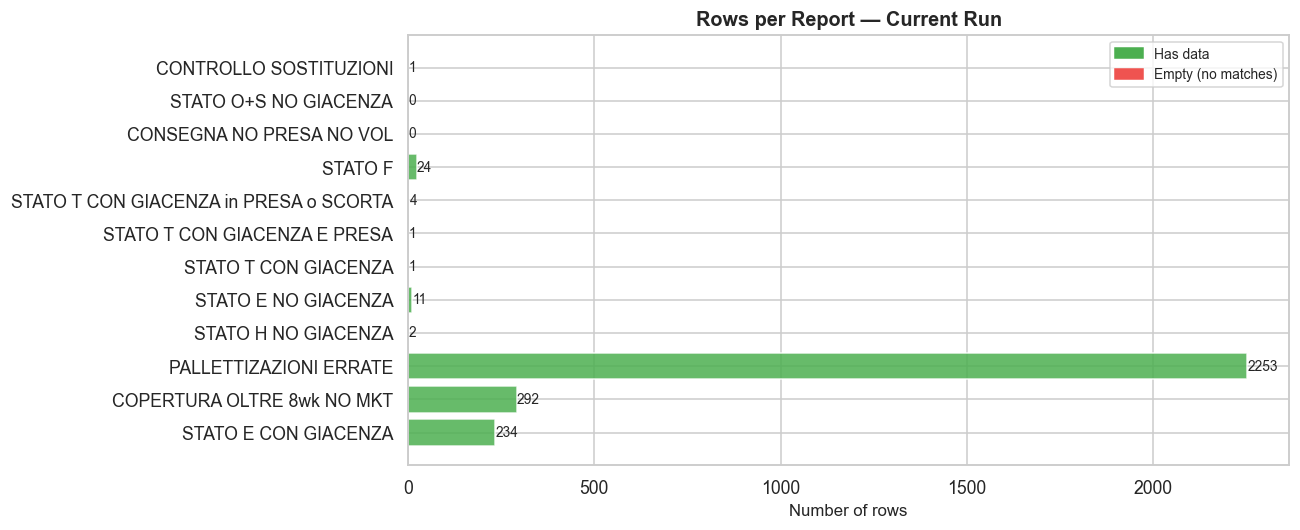

Chart saved → tablescreator_summary.png


In [19]:
if _saved:
    fig, ax = plt.subplots(figsize=(12, 5))
    names  = [r.replace('.xlsx', '').replace('_', ' ') for r, _, _ in _saved]
    rows   = [r for _, r, _ in _saved]
    colors = ['#4CAF50' if r > 0 else '#EF5350' for r in rows]
    bars   = ax.barh(names, rows, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Number of rows', fontsize=11)
    ax.set_title('Rows per Report — Current Run', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, rows):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    green_patch = mpatches.Patch(color='#4CAF50', label='Has data')
    red_patch   = mpatches.Patch(color='#EF5350', label='Empty (no matches)')
    ax.legend(handles=[green_patch, red_patch], fontsize=9)
    plt.tight_layout()
    plt.savefig('tablescreator_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Chart saved → tablescreator_summary.png')

---
## Notes

**Input files required** (in `./INPUT/`):

| File | Content |
|---|---|
| Rotazioni.xlsx | Article rotation and coverage data |
| Sostituzioni.xlsx | Substitution mapping |
| Ordini Fornitori.xlsx | Open supplier orders |
| Mappa Prese.xlsx | Shelf slot mapping |
| BuyerApprov.xlsx | Buyer/approver name lookup |
| Giacenza Corsie.xlsx | Aisle stock quantities |
| Controllo Anagrafica.xlsx | Article master data + dimensions |

**Key design decisions:**
- `add_buyer_names()` centralizes the buyer enrichment logic (was repeated 6× in the original script)
- `RENAME_DESC_STATO` / `RENAME_POSIZIONE` dicts eliminate repeated rename blocks
- `load_excel()` validates all files upfront — script halts before any processing if a file is missing
- `save()` logs every output to `_saved` for the final summary chart

---
*Giuseppe Iaccarino — December 2022 / Refactored 2026*